# **Handling CMIP6 Data**

An important part of CMIP is to make the multi-model output publicly available in a **standardized format** for analysis by the wider climate community and users. The standardization of the model output in a specified format, and the collection, archival, and access of the model output through the Earth System Grid Federation ([ESGF](https://esgf.llnl.gov/)) data replication centres have facilitated multi-model analyses.

The CMIP6 model output is stored in **netCDF** files. netCDF stands for “Network Common Data Form” and is a data format which is commonly used to store and share large, array-oriented scientific data. It is self-describing, portable, metadata friendly and supported by many languages (including python, R, fortran, C/C++, Matlab, NCL, etc.). It is commonly used for gridded model outputs and related to the HDF and CDF formats, which you might have stumbled upon. 

**All metadata** about the model output is stored **within the netCDF file**'s metadata. You can also understand the **attributes** of an output file from its path (e.g., shared-clinfra-ns12127k-ns9560k-datalake/ESGF/CMIP6/activity_id/institute_id/model-id/experiment_id/variant_id/table_id/variable_id/grid_id/version/files) and the filenames itself. Attributes are for example the model institute, the name of the model, the experiment/climate scenario, the grid, the output variable and many more. **Intake catalog** containes these attributes and allowse you to browse the available data without browsing the folder structure.

Useful links for **navigating the output**:
* [CMIP6 attribute list](https://wcrp-cmip.github.io/WGCM_Infrastructure_Panel/Papers/CMIP6_global_attributes_filenames_CVs_v6.2.7.pdf)
* [CMIP6 data frenquency list](https://clipc-services.ceda.ac.uk/dreq/index/miptable.html)
* [CMIP6 variables list](https://clipc-services.ceda.ac.uk/dreq/index/var.html)

For downloading CMIP6 data yourself (in the future, not needed here):
* [ESGF CMIP6 data search and download portal](https://esgf-node.llnl.gov/search/cmip6/)
* [CMIP6 data request home page](https://clipc-services.ceda.ac.uk/dreq/index.html)
* [CMIP6 data request overview paper: Juckes et al., 2020](https://gmd.copernicus.org/articles/13/201/2020/)

## Open a model output file

In [1]:
#import Python packages that make working with labelled multi-dimensional arrays simple and efficient
import xarray as xr
import pandas as pd
import matplotlib as mpl

%matplotlib inline

**OBS!** When specifying a filepath, instead of using the path from your home directory, use the global path **'/mnt/clinfra-ns12127k-*'**

In [2]:
filepath = '/mnt/clinfra-ns12127k-ns9560k-datalake/ESGF/CMIP6/CMIP/AWI/AWI-CM-1-1-MR/1pctCO2/r1i1p1f1/Amon/ta/gn/latest/ta_Amon_AWI-CM-1-1-MR_1pctCO2_r1i1p1f1_gn_185001-185012.nc'
# read in the data using the xarray package. the resulting variable 'dataset' the is an xarray
data = xr. open_dataset(filepath)

/opt/conda/envs/pangeo/lib/python3.12/site-packages/dask/config.py:786: FutureWarning: Dask configuration key 'distributed.p2p.disk' has been deprecated; please use 'distributed.p2p.storage.disk' instead
  warnings.warn(


Inspect the data: 
- What are all the 'Data variables'?
- What is the output variable in this file?
- Find more information about the dataset on the landing page

In [3]:
data

<xarray.Dataset> Size: 67MB
Dimensions:    (time: 12, bnds: 2, lat: 192, lon: 384, plev: 19)
Coordinates:
  * time       (time) datetime64[ns] 96B 1850-01-16T12:00:00 ... 1850-12-16T1...
  * lat        (lat) float64 2kB -89.28 -88.36 -87.42 ... 87.42 88.36 89.28
  * lon        (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * plev       (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 192B ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 6kB ...
    ta         (time, plev, lat, lon) float32 67MB ...
Attributes: (12/44)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  90945.0
    creation_date:          2019-04-26T13:09:16Z
    ...                     ...
    title:                  AWI-CM-1-1-MR output prepared for CMIP6
    variable_id:            ta
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by Alfred Wegener Insti...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/a0972ca7-5e32-4f92-96d7-e865c7397c0e

We can **adress the variable of interest** via *name_of_xarray.name_of_variable* 

In [60]:
data.ta

<xarray.DataArray 'ta' (time: 12, plev: 19, lat: 192, lon: 384)> Size: 67MB
[16809984 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 96B 1850-01-16T12:00:00 ... 1850-12-16T12:...
  * plev     (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * lat      (lat) float64 2kB -89.28 -88.36 -87.42 -86.49 ... 87.42 88.36 89.28
  * lon      (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
Attributes:
    standard_name:  air_temperature
    long_name:      Air Temperature
    comment:        Air Temperature
    units:          K
    original_name:  st
    cell_methods:   time: mean
    cell_measures:  area: areacella
    history:        2019-04-26T13:09:16Z altered by CMOR: Reordered dimension...

To obtain a **slice** of the data we can use the [isel()](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.isel.html) function to choose the index (of time, lat, lon, pressure level..) or the or the [sel()](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.sel.html) function to label (time, lat, lon, pressure level...) explicitely.

In [61]:
data.ta.isel(time=0)

<xarray.DataArray 'ta' (plev: 19, lat: 192, lon: 384)> Size: 6MB
[1400832 values with dtype=float32]
Coordinates:
    time     datetime64[ns] 8B 1850-01-16T12:00:00
  * plev     (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * lat      (lat) float64 2kB -89.28 -88.36 -87.42 -86.49 ... 87.42 88.36 89.28
  * lon      (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
Attributes:
    standard_name:  air_temperature
    long_name:      Air Temperature
    comment:        Air Temperature
    units:          K
    original_name:  st
    cell_methods:   time: mean
    cell_measures:  area: areacella
    history:        2019-04-26T13:09:16Z altered by CMOR: Reordered dimension...

In [62]:
data.ta.sel(time='1850-01-16T12:00:00')

<xarray.DataArray 'ta' (plev: 19, lat: 192, lon: 384)> Size: 6MB
[1400832 values with dtype=float32]
Coordinates:
    time     datetime64[ns] 8B 1850-01-16T12:00:00
  * plev     (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * lat      (lat) float64 2kB -89.28 -88.36 -87.42 -86.49 ... 87.42 88.36 89.28
  * lon      (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
Attributes:
    standard_name:  air_temperature
    long_name:      Air Temperature
    comment:        Air Temperature
    units:          K
    original_name:  st
    cell_methods:   time: mean
    cell_measures:  area: areacella
    history:        2019-04-26T13:09:16Z altered by CMOR: Reordered dimension...

# Visualize the data

Before plotting, think about **what you want to plot** and how your data are **structured**. Most output files are 3- or 4-dimensional. Your screen has 2 dimensions. What do you want to investigate? How do you need to slice the xarray-field in order to get those data?

## Maps
= Visualizing your variable of interest spatially, at one point in time (aka keep lat and lon gridding, specify time)

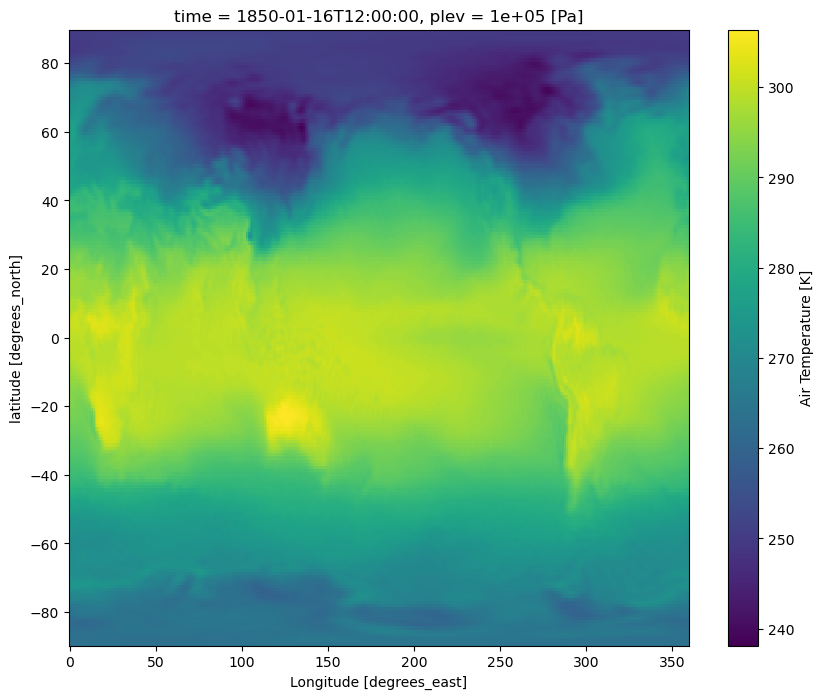

In [64]:
data.ta.sel(time='1850-01-16T12:00:00').isel(plev=0).plot()

### Set Figure Size
To adjust the figure, we can use the matplotlib package:

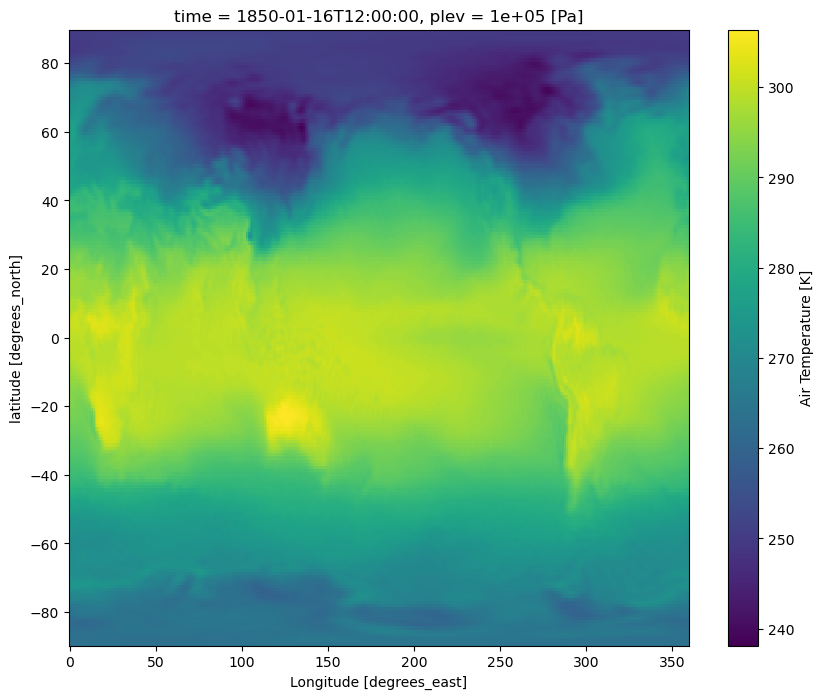

In [65]:
#import python package
import matplotlib as mpl

#adjust figure size
mpl.rcParams['figure.figsize'] = [10., 8.]
data.ta.sel(time='1850-01-16T12:00:00').isel(plev=0).plot()

## Change the Map Projection
We can use the Python package Cartopy to produce maps and do other geospatial data analyses. We will also use pyplot, a collection of functions that make plotting simpler.

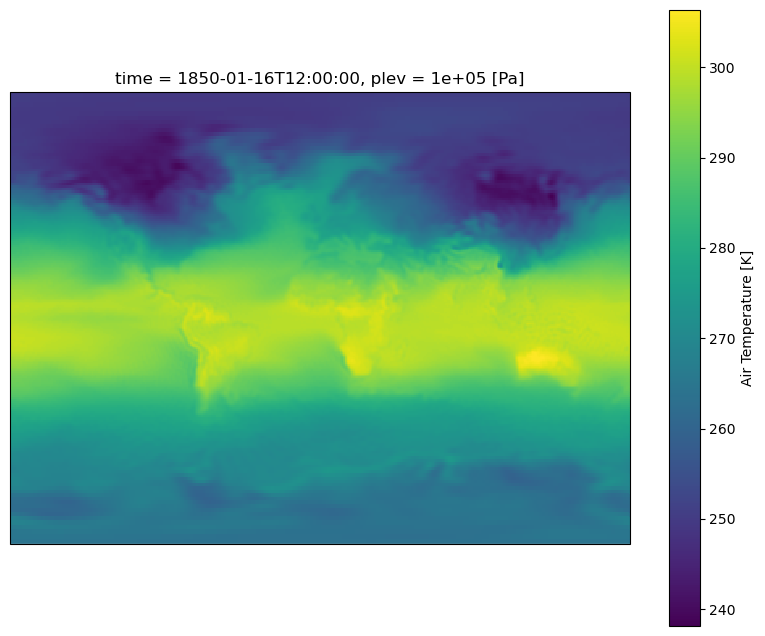

In [66]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

fig = plt.figure()
ax = plt.axes(projection=ccrs.Miller())

data.ta.sel(time='1850-01-16T12:00:00').isel(plev=0).plot(ax=ax, 
           transform=ccrs.PlateCarree()
          )

When changing th projection, the lat/lon labelling disappeared. Not all projections support lat/lon labelling. The *PlateCarree* and *Mercator* projections do support lat/lon labelling. You can also add coastlines.

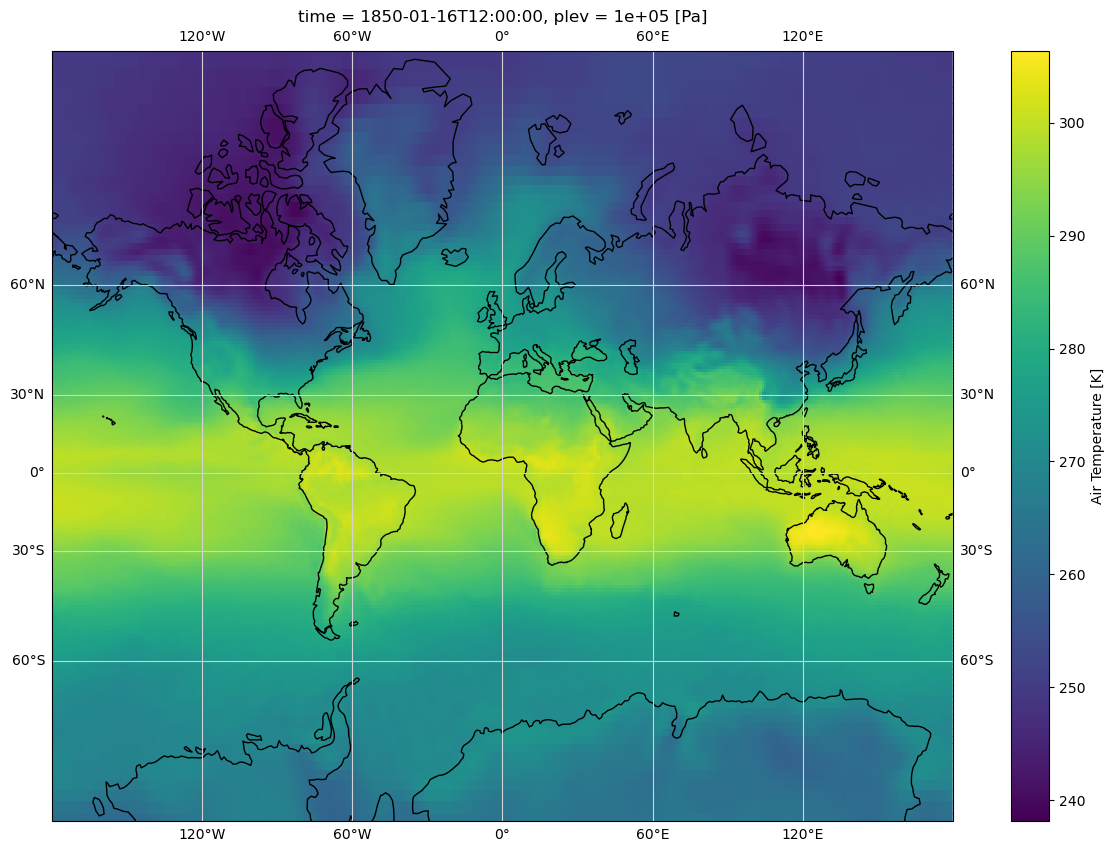

In [67]:
fig = plt.figure(figsize=(15,10))
ax = plt.axes(projection=ccrs.Mercator())

data.ta.sel(time='1850-01-16T12:00:00').isel(plev=0).plot(ax=ax, 
           transform=ccrs.PlateCarree()
          )

ax.coastlines()

# Add gridlines with labels
gl = ax.gridlines(color='lightgrey', linestyle='-', draw_labels=True)

# Do not draw labels on the top and right of the map.
gl.xlabels_top = False
gl.ylabels_right = False

### Georeferenced Latitude-Vertical Plots

**2D plot for one longitude point**: Use the sel() function to select the data along one latitude and at one time:

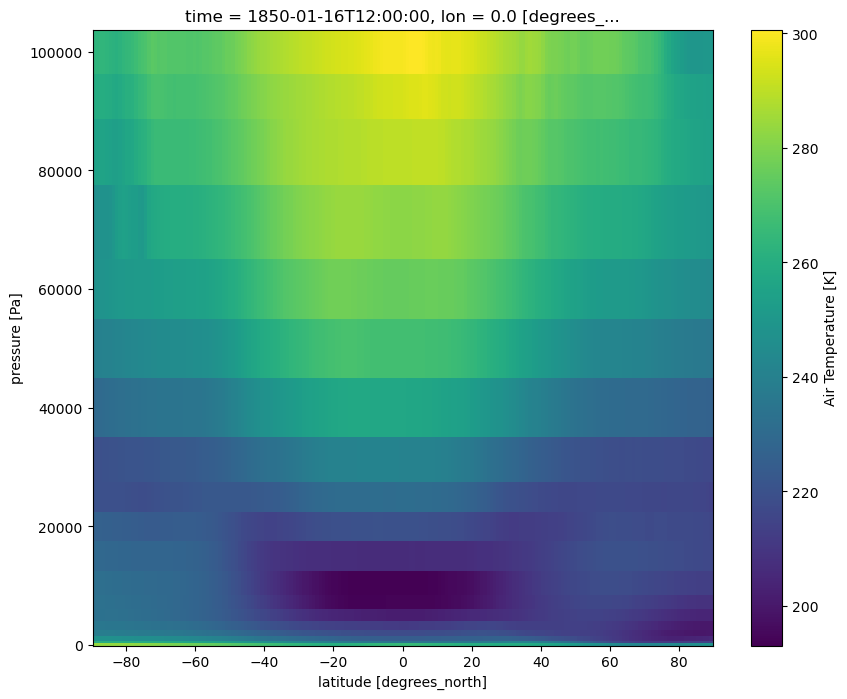

In [68]:
data.ta.sel(lon='0',time='1850-01-16T12:00:00').plot()

Having pressure values as the vertical coordinate, it is clear that we need to revert the vertical axis to get the lower values at the top and the highest values at the bottom:

(103750.0, -100.0)

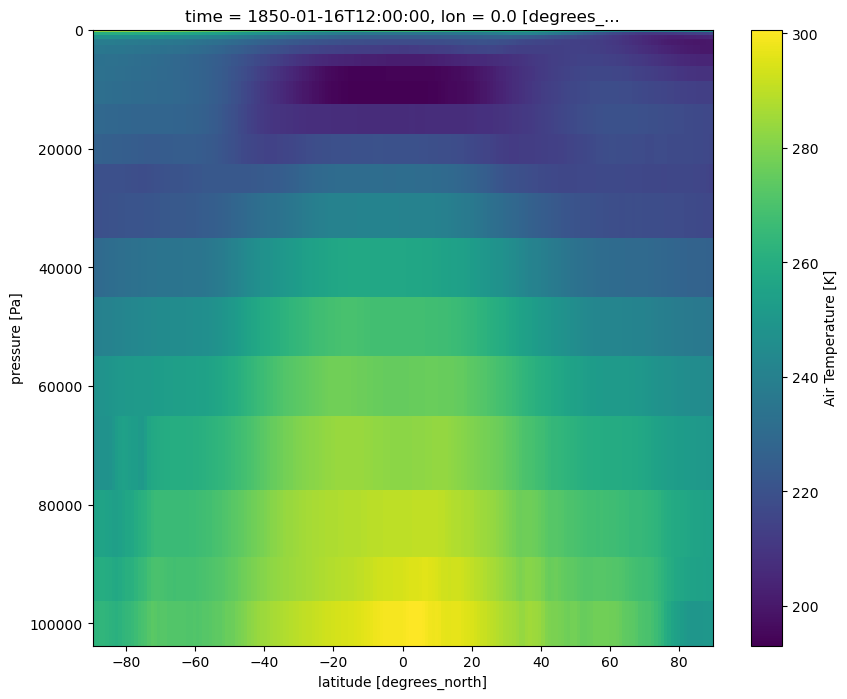

In [69]:
data.ta.sel(lon='0',time='1850-01-16T12:00:00').plot()
plt.ylim(plt.ylim()[::-1])

For pressure levels, we usually use hPa instead of Pa. 

- How many hPa are 1 atm? 

Change the pressure levels from Pa to hPa:

In [75]:
# change pressure level from Pa to hPa within your dataset and change the attribute description and units such that things don't get messy
hpa=data.plev/100
data['plev']=hpa
data.plev.attrs['units'] = 'hPa'
data.plev.attrs['standard_name'] = 'air_pressure'
data.plev

<xarray.DataArray 'plev' (plev: 19)> Size: 152B
array([1000.,  925.,  850.,  700.,  600.,  500.,  400.,  300.,  250.,  200.,
        150.,  100.,   70.,   50.,   30.,   20.,   10.,    5.,    1.])
Coordinates:
  * plev     (plev) float64 152B 1e+03 925.0 850.0 700.0 ... 20.0 10.0 5.0 1.0
Attributes:
    units:          hPa
    standard_name:  air_pressure

(1037.5, -1.0)

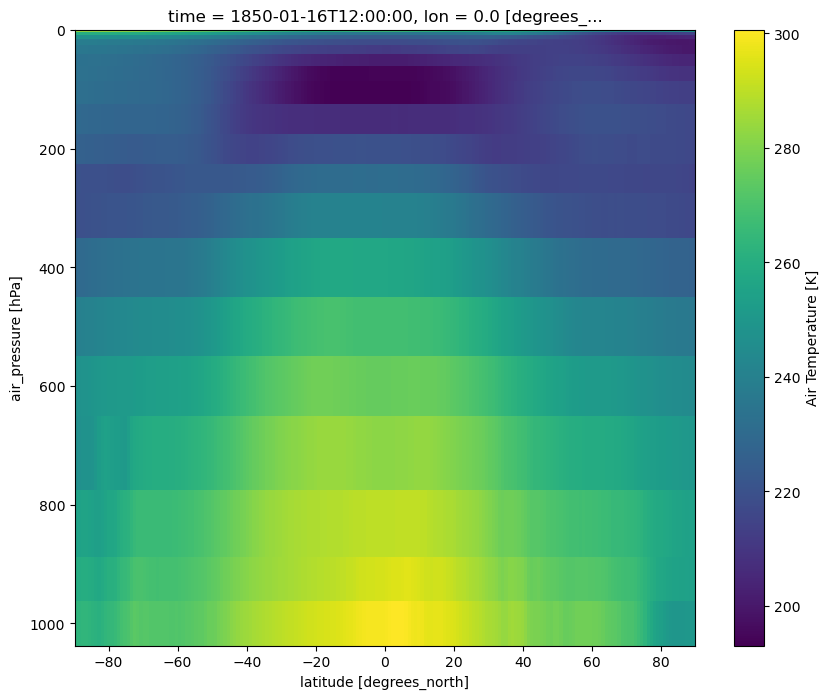

In [76]:
# plot
data.ta.sel(lon='0',time='1850-01-16T12:00:00').plot()
plt.ylim(plt.ylim()[::-1])

We can also adjust the top of the figure. When the vertical axis is pressure levels, we can use a log scale to plot it so as to make it more intuitive to look at.

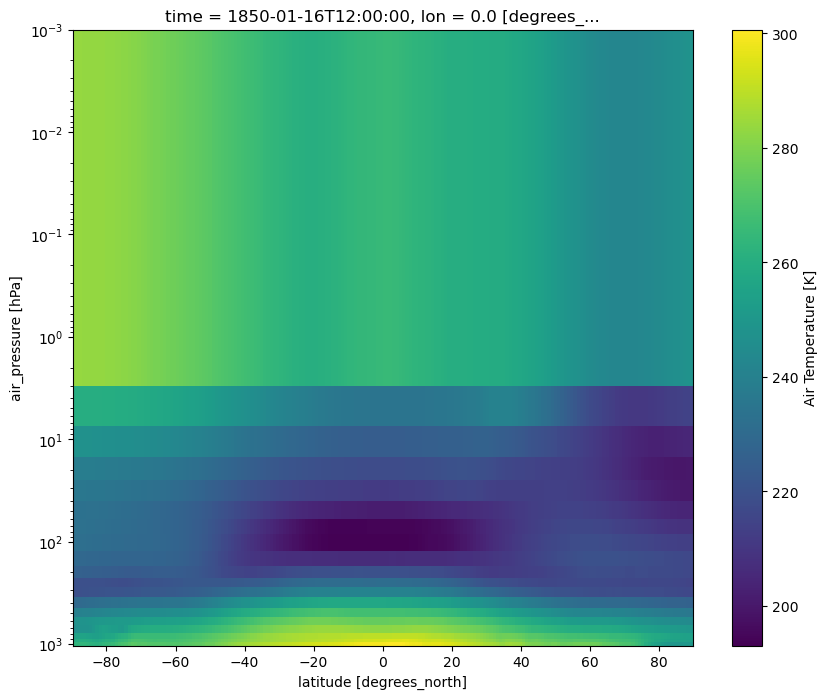

In [77]:
data.ta.sel(lon='0',time='1850-01-16T12:00:00').plot()
plt.ylim(plt.ylim()[::-1])
plt.ylim(top=0.001)
plt.yscale('log')

## 2D plot over averaged longitudes

Instead of selecting one longitude, we can also average over all the longitudes, using the mean function:

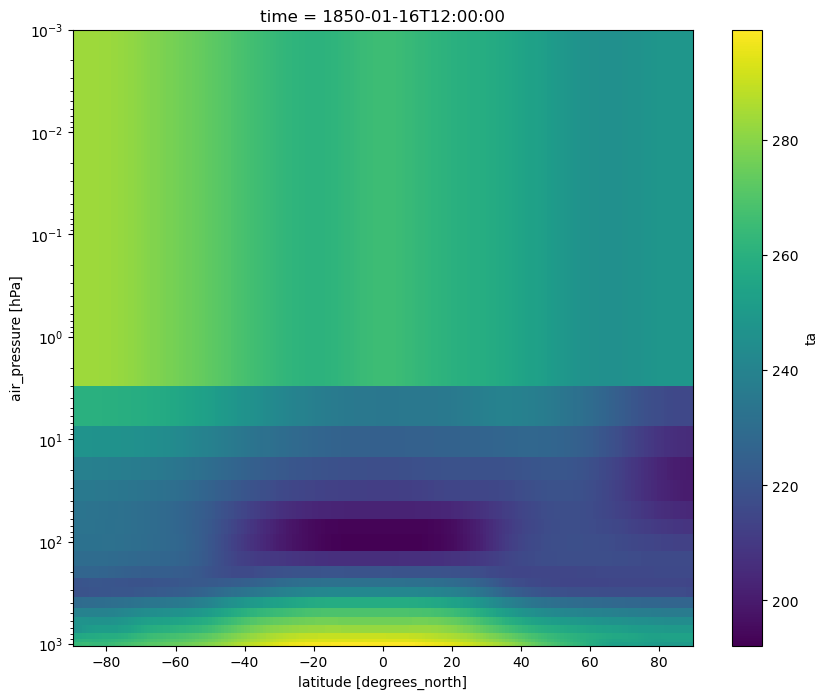

In [80]:
data.ta.sel(time='1850-01-16T12:00:00').mean(dim='lon').plot()
plt.ylim(plt.ylim()[::-1])
plt.ylim(top=0.001)
plt.yscale('log')

- There are many more functions available for [xarray](https://docs.xarray.dev/en/stable/getting-started-guide/why-xarray.html), make yourself familiar with these!
- You can (and should) also experiment with colormaps. These can be parsed to the .plot() function, google!